# Import necessary modules

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load and preprocess MNIST dataset

In [3]:
(trainX, trainY), (testX, testY) = mnist.load_data()
trainX, testX = trainX/255.0, testX/255.0
trainX = trainX.reshape(-1, 784)
testX = testX.reshape(-1, 784)
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

In [4]:
trainX.shape, trainY.shape, testX.shape, testY.shape

((60000, 784), (60000, 10), (10000, 784), (10000, 10))

# Build the model

In [5]:
class MLP(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(8, activation='relu')
        self.d2 = tf.keras.layers.Dense(4, activation='relu')
        self.d3 = tf.keras.layers.Dense(4, activation='relu')
        self.out = tf.keras.layers.Dense(10, activation='softmax')

    def call(self, x):
        x = self.d1(x)
        x = self.d2(x)
        x = self.d3(x)
        return self.out(x)

gradient_tape_model = MLP()

# Loss function and optimizer

In [6]:
loss_function = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# Training loop (using gradient tape)

In [7]:
EPOCHS = 10
BATCH_SIZE = 128

train_test_split = int(0.8 * len(trainX))
# Corrected slicing for train and validation sets
trainX_split = trainX[:train_test_split]
trainY_split = trainY[:train_test_split]
valX = trainX[train_test_split:]
valY = trainY[train_test_split:]

# Create training dataset
train_ds = tf.data.Dataset.from_tensor_slices((trainX_split, trainY_split))
train_ds = train_ds.shuffle(buffer_size=10000).batch(BATCH_SIZE)

# Create validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((valX, valY))
val_ds = val_ds.batch(BATCH_SIZE)

for epoch in range(EPOCHS):
    # Training loop
    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            probs = gradient_tape_model(x_batch)
            loss = loss_function(y_batch, probs)
        grads = tape.gradient(loss, gradient_tape_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, gradient_tape_model.trainable_variables))

    # Validation loop
    val_losses = []
    val_accuracy = tf.keras.metrics.CategoricalAccuracy()

    for x_val_batch, y_val_batch in val_ds:
        val_probs = gradient_tape_model(x_val_batch)
        val_loss = loss_function(y_val_batch, val_probs)
        val_losses.append(val_loss.numpy())
        val_accuracy.update_state(y_val_batch, val_probs)

    val_loss_avg = sum(val_losses) / len(val_losses)

    print(f"Epoch {epoch+1}: Training Loss = {loss.numpy():.4f}, "
          f"Validation Loss = {val_loss_avg:.4f}, "
          f"Validation Accuracy = {val_accuracy.result().numpy():.4f}")

Epoch 1: Training Loss = 0.6849, Validation Loss = 0.7231, Validation Accuracy = 0.7697
Epoch 2: Training Loss = 0.8508, Validation Loss = 0.6104, Validation Accuracy = 0.8231
Epoch 3: Training Loss = 0.6615, Validation Loss = 0.5892, Validation Accuracy = 0.8282
Epoch 4: Training Loss = 0.7072, Validation Loss = 0.5272, Validation Accuracy = 0.8515
Epoch 5: Training Loss = 0.4079, Validation Loss = 0.5413, Validation Accuracy = 0.8480
Epoch 6: Training Loss = 0.5263, Validation Loss = 0.5139, Validation Accuracy = 0.8572
Epoch 7: Training Loss = 0.5559, Validation Loss = 0.5515, Validation Accuracy = 0.8471
Epoch 8: Training Loss = 0.5121, Validation Loss = 0.5126, Validation Accuracy = 0.8567
Epoch 9: Training Loss = 0.4735, Validation Loss = 0.5234, Validation Accuracy = 0.8513
Epoch 10: Training Loss = 0.3897, Validation Loss = 0.5173, Validation Accuracy = 0.8622


# Training using model.fit()

In [8]:
# Instantiate and compile the model
keras_fit_model = MLP()
keras_fit_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

# Train using fit
keras_fit_model.fit(trainX, trainY, batch_size=64, epochs=10, validation_split=0.2)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4433 - loss: 1.5171 - val_accuracy: 0.7983 - val_loss: 0.6418
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8024 - loss: 0.6615 - val_accuracy: 0.8283 - val_loss: 0.5995
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8282 - loss: 0.6011 - val_accuracy: 0.8403 - val_loss: 0.5505
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8367 - loss: 0.5700 - val_accuracy: 0.8427 - val_loss: 0.5498
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8431 - loss: 0.5536 - val_accuracy: 0.8496 - val_loss: 0.5348
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8453 - loss: 0.5462 - val_accuracy: 0.8553 - val_loss: 0.5333
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8449 - loss: 0.5498 - val_accuracy: 0.8572 - val_loss: 0.5244
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8513 - loss: 0.5250 - val_accuracy: 0.

# Model evaluation

In [9]:
def evaluate(model, testX):
    y_pred_prob = model(testX)
    y_pred = tf.argmax(y_pred_prob, axis=1)
    y_true = tf.argmax(testY, axis=1)

    acc = tf.reduce_mean(tf.cast(tf.equal(y_pred, y_true), tf.float32))
    return acc

In [10]:
print(f"Gradient Tape model accuracy: {evaluate(gradient_tape_model, testX) * 100:.2f}%")
print(f"Keras fit model accuracy: {evaluate(keras_fit_model, testX) * 100:.2f}%")

Gradient Tape model accuracy: 84.85%
Keras fit model accuracy: 85.12%


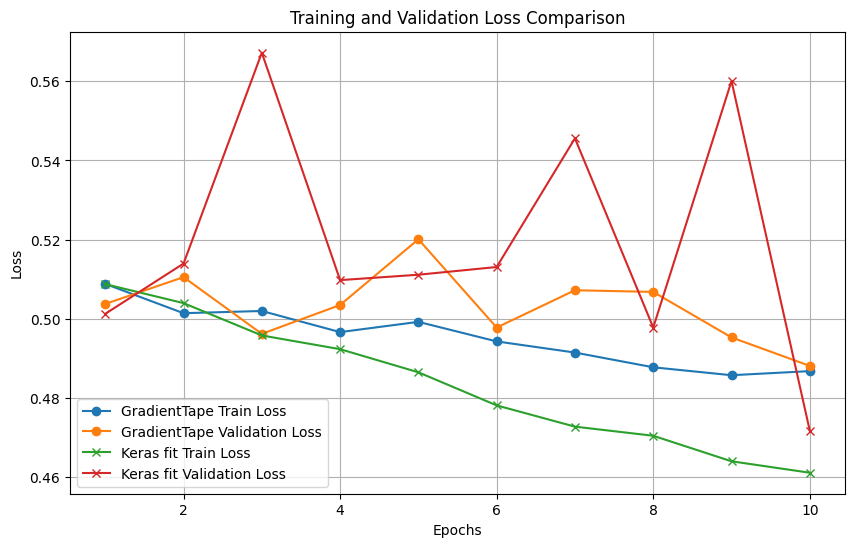

In [11]:
import matplotlib.pyplot as plt

# Store losses
train_losses = []
val_losses = []

# Training loop for GradientTape model
for epoch in range(EPOCHS):
    epoch_train_loss = 0
    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            probs = gradient_tape_model(x_batch)
            loss = loss_function(y_batch, probs)
        grads = tape.gradient(loss, gradient_tape_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, gradient_tape_model.trainable_variables))
        epoch_train_loss += loss.numpy() * x_batch.shape[0]

    train_loss_avg = epoch_train_loss / len(trainX_split)

    # Validation loss
    val_loss_total = 0
    for x_val_batch, y_val_batch in val_ds:
        val_probs = gradient_tape_model(x_val_batch)
        val_loss_total += loss_function(y_val_batch, val_probs).numpy() * x_val_batch.shape[0]
    val_loss_avg = val_loss_total / len(valX)

    train_losses.append(train_loss_avg)
    val_losses.append(val_loss_avg)

# Train Keras fit model and get history
history = keras_fit_model.fit(trainX, trainY, batch_size=64, epochs=EPOCHS, validation_split=0.2, verbose=0)

# Plot
plt.figure(figsize=(10,6))
plt.plot(range(1, EPOCHS+1), train_losses, label='GradientTape Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses, label='GradientTape Validation Loss', marker='o')
plt.plot(range(1, EPOCHS+1), history.history['loss'], label='Keras fit Train Loss', marker='x')
plt.plot(range(1, EPOCHS+1), history.history['val_loss'], label='Keras fit Validation Loss', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()
